# Verify Classifier ONNX Export

This notebook compares the TensorFlow/Keras classifier output with the exported ONNX model.

Goals:
- load TensorFlow and ONNX classifier models
- run both models on the same input
- compare output vectors
- verify that predicted class remains identical
- save comparison figures for thesis documentation

In [ ]:
from pathlib import Path
import numpy as np
import tensorflow as tf
import onnxruntime as ort

from project_config import (
    PROJECT_ROOT,
    CLASSIFIER_MODEL_PATH,
    CLASSIFIER_ONNX_PATH,
    CLASSIFIER_IMG_SIZE,
    SEED,
    REPORTS_DIR,
    CLASSIFIER_TF_VS_ONNX_FIGURE,
    CLASSIFIER_ONNX_ABS_DIFF_FIGURE,
    ONNX_VERIFICATION_THRESHOLD,
)

# =========================================================
# SETTINGS
# =========================================================
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# DIAGNOSTICS
# ========================================================= 
print("CWD:", Path.cwd())
print("PROJECT_ROOT:", PROJECT_ROOT)
print("TF_MODELS_DIR:", TF_MODELS_DIR)
print("ONNX_DIR:", ONNX_DIR)
print("TF_CLASSIFIER_PATH:", CLASSIFIER_MODEL_PATH)
print("ONNX_CLASSIFIER_PATH:", CLASSIFIER_ONNX_PATH)

assert CLASSIFIER_MODEL_PATH.exists(), f"Missing TF model: {CLASSIFIER_MODEL_PATH}"
assert CLASSIFIER_ONNX_PATH.exists(), f"Missing ONNX model: {CLASSIFIER_ONNX_PATH}"

# =========================================================
# LOAD MODELS
# =========================================================
tf_model = tf.keras.models.load_model(CLASSIFIER_MODEL_PATH, compile=False)

ort_session = ort.InferenceSession(
    str(CLASSIFIER_ONNX_PATH),
    providers=["CPUExecutionProvider"],
)

print("\nONNX inputs:")
for i, inp in enumerate(ort_session.get_inputs()):
    print(f"  [{i}] name={inp.name}, shape={inp.shape}, type={inp.type}")

print("\nONNX outputs:")
for i, out in enumerate(ort_session.get_outputs()):
    print(f"  [{i}] name={out.name}, shape={out.shape}, type={out.type}")

assert len(ort_session.get_inputs()) == 1, (
    f"Expected exactly one ONNX input for classifier, got {len(ort_session.get_inputs())}. "
    "Classifier should be re-exported."
)

input_name = ort_session.get_inputs()[0].name
output_name = ort_session.get_outputs()[0].name

# =========================================================
# TEST INPUT
# =========================================================
x = np.random.rand(1, CLASSIFIER_IMG_SIZE[0], CLASSIFIER_IMG_SIZE[1], 3).astype(np.float32) * 255.0
x_tf = tf.keras.applications.efficientnet.preprocess_input(x.copy()).astype(np.float32)

# =========================================================
# INFERENCE
# =========================================================
tf_raw = tf_model(x_tf, training=False)
tf_out = tf_raw.numpy() if hasattr(tf_raw, "numpy") else np.asarray(tf_raw)

onnx_out = ort_session.run([output_name], {input_name: x_tf})[0]

# =========================================================
# COMPARISON
# =========================================================
max_abs_diff = float(np.max(np.abs(tf_out - onnx_out)))
mean_abs_diff = float(np.mean(np.abs(tf_out - onnx_out)))

print("\ninput_name:", input_name)
print("output_name:", output_name)
print("tf_out shape:", tf_out.shape)
print("onnx_out shape:", onnx_out.shape)
print("max_abs_diff:", max_abs_diff)
print("mean_abs_diff:", mean_abs_diff)
print("tf argmax:", int(np.argmax(tf_out[0])))
print("onnx argmax:", int(np.argmax(onnx_out[0])))

Počet tříd: 6
TF argmax: 3
ONNX argmax: 3


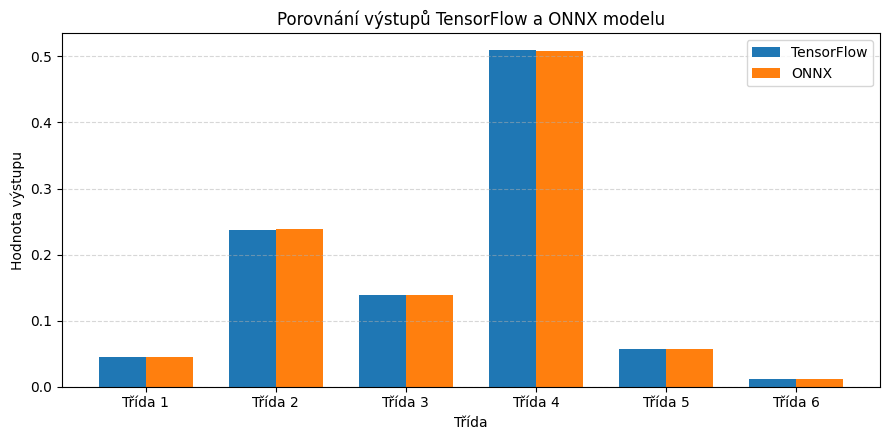

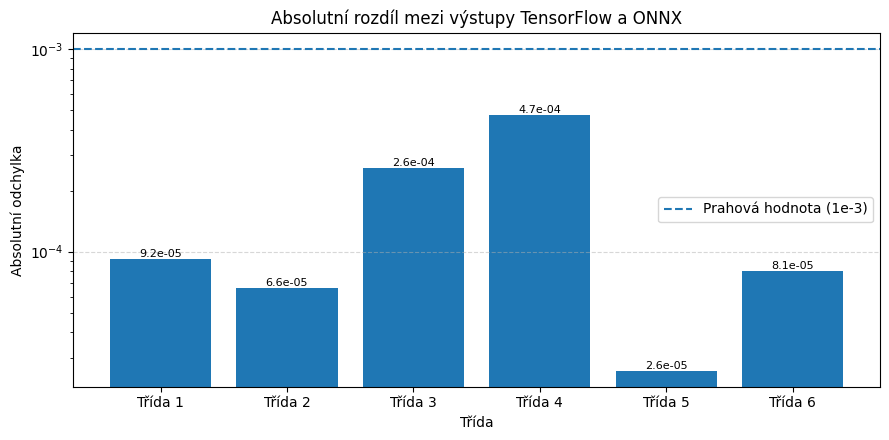

Saved: /workspace/models/reports/classifier_tf_vs_onnx.png
Saved: /workspace/models/reports/classifier_abs_diff.png
max_abs_diff: 0.00047010183334350586
mean_abs_diff: 0.0001653139479458332
same_argmax: True


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# CHECK
# =========================================================
assert "tf_out" in globals(), "Missing tf_out. Run the verification cell first."
assert "onnx_out" in globals(), "Missing onnx_out. Run the verification cell first."

# =========================================================
# DATA
# =========================================================
tf_vals = np.asarray(tf_out[0], dtype=np.float64)
onnx_vals = np.asarray(onnx_out[0], dtype=np.float64)
abs_diff = np.abs(tf_vals - onnx_vals)

class_labels = [f"Třída {i+1}" for i in range(len(tf_vals))]
x = np.arange(len(class_labels))

print("Počet tříd:", len(class_labels))
print("TF argmax:", int(np.argmax(tf_vals)))
print("ONNX argmax:", int(np.argmax(onnx_vals)))

# =========================================================
# FIGURE 1: TF vs ONNX
# =========================================================
width = 0.36

plt.figure(figsize=(9, 4.5))
plt.bar(x - width / 2, tf_vals, width, label="TensorFlow")
plt.bar(x + width / 2, onnx_vals, width, label="ONNX")

plt.xticks(x, class_labels)
plt.ylabel("Hodnota výstupu")
plt.xlabel("Třída")
plt.title("Porovnání výstupů TensorFlow a ONNX modelu")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

fig1_path = CLASSIFIER_TF_VS_ONNX_FIGURE
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# FIGURE 2: ABSOLUTE DIFFERENCE
# =========================================================
# log scale nesnese nuly -> použijeme malou epsilon hodnotu jen pro vykreslení
eps = 1e-12
abs_diff_plot = np.maximum(abs_diff, eps)

plt.figure(figsize=(9, 4.5))
bars = plt.bar(x, abs_diff_plot)

plt.xticks(x, class_labels)
plt.ylabel("Absolutní odchylka")
plt.xlabel("Třída")
plt.title("Absolutní rozdíl mezi výstupy TensorFlow a ONNX")
plt.yscale("log")

threshold = ONNX_VERIFICATION_THRESHOLD
plt.axhline(threshold, linestyle="--", label="Prahová hodnota (1e-3)")

for i, v in enumerate(abs_diff):
    text_y = max(v, eps)
    plt.text(i, text_y, f"{v:.1e}", ha="center", va="bottom", fontsize=8)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

fig2_path = CLASSIFIER_ONNX_ABS_DIFF_FIGURE
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# STATS
# =========================================================
print("Saved:", fig1_path)
print("Saved:", fig2_path)
print("max_abs_diff:", float(np.max(abs_diff)))
print("mean_abs_diff:", float(np.mean(abs_diff)))
print("same_argmax:", int(np.argmax(tf_vals)) == int(np.argmax(onnx_vals)))